# Cruciform Fixed Source Problem

In [1]:
# Change start method form 'fork' for clusters
import multiprocessing
multiprocessing.set_start_method('forkserver')

import matplotlib.pyplot as plt
import numpy as np
import torch as tn
from igakit import cad

from ttnte.xs.benchmarks import Server
from ttnte.iga import IGAMesh
from ttnte.assemblers import MatrixAssembler, TTAssembler
from ttnte.linalg import LinearOperator, fixed_source
from ttnte.cad import Patch
from ttnte.cad.curves import qtrlobe
from ttnte.sources import IsotropicInternalSource
from mpl_toolkits.axes_grid1 import make_axes_locatable

tn.set_default_dtype(tn.float64)

## Define Cross Section Library and IGA Mesh

In [2]:
# Discretization
num_ordinates = 1024

# Get XS data
xs_server = Server(
    {
        "Source": {
            "total": np.array([0.1]),
            "scatter_gtg": np.array([[[0.08]]]),
        },
        "Void": {
            "total": np.array([0]),
            "scattering_gtg": np.array([[[0]]]),
        },
        "Wall": {
            "total": np.array([1]),
            "scattering_gtg": np.array([[[0.1]]]),
        }
    }
)

In [3]:
## Initialize dimensional variables
X = 1.6 # Channel pitch

# Cruciform
R = 0.297 # Radius defining valleys of fixed source
delta = 0.306 # Width of lobes
d2 = delta * 0.5 # Half width of lobes
x = 0.18 # Portrusion of lobes

# Shielding
I = 0.7 # Inner radius
O = 0.75 # Outer radius

# NURBS curves
origin = cad.line(p0=(0, 0), p1=(0, 0))
cruciform = qtrlobe(outrad = R, portrs = x, hfwidth = d2)
circleI = cad.circle(radius = I, angle = [np.pi/2, 0] )
circleO = cad.circle(radius = O, angle = [np.pi/2, 0] )
topedge = cad.line(p0=(0, X / 2), p1=(X / 2, X / 2))
corner = cad.line(p1=(X / 2, X / 2), p0=(X / 2, X / 2))
rightedge = cad.line(p1=(X / 2, 0), p0=(X / 2, X / 2))

In [4]:
# Create IGA mesh object
mesh = IGAMesh()

# Create and add NURBS surfaces
sections = [0, 1/3, 2/3, 1]
edges = [topedge, corner, rightedge]

for i in range(len(sections) - 1):
    # Line sections
    csec = origin.slice(0, sections[i], sections[i + 1])
    ssec = cruciform.slice(0, sections[i], sections[i + 1])
    isec = circleI.slice(0, sections[i], sections[i + 1])
    osec = circleO.slice(0, sections[i], sections[i + 1])

    # Create source patch
    source = Patch(cad.ruled(csec, ssec), "Source")
    source.set_source(IsotropicInternalSource(np.ones((1, *source.shape))))
    mesh.add_patch(source)

    # Add remaining
    mesh.add_patch(Patch(cad.ruled(ssec, isec), "Void"))
    mesh.add_patch(Patch(cad.ruled(isec, osec), "Wall"))
    #mesh.add_patch(Patch(cad.ruled(osec, edges[i]), "Void"))

In [5]:
# Refine mesh resolution
mesh.refine(factor=7, degree=2)

# Connect patches
mesh.connect()

# Set reflective boundary conditions
mesh.set_reflective_conditions(("left", "bottom"))

# Finalize mesh
mesh.finalize()
mesh

IGAMesh(id=0, name=None, num_patches=9, reflective_boundaries=True)
  -> Patch(material=Source, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7f90cb17f390>, id=0, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Void, source=None, id=1, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Wall, source=None, id=2, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Source, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7f90cb17f490>, id=3, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Void, source=None, id=4, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Wall, source=None, id=5, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Source, source=<ttnte.sources.isotropic_internal_source.IsotropicInternalSource object at 0x7f90cb17ff50>, id=6, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Void, source=None, id=7, name=None, shape=(9, 9), backend=geomdl)
  -> Patch(material=Wall, source=None, id=8, name=None, shape=(9, 9), backend=geomdl)

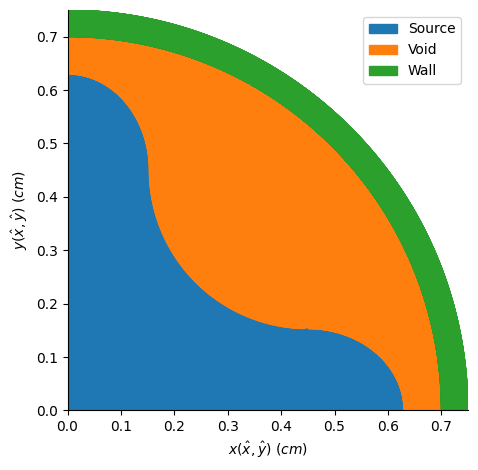

In [6]:
# Plot final mesh
ax = mesh.plot(plot_ctrlpts=False)
plt.tight_layout()
plt.savefig("./figs/cruciform.png", dpi=300)
plt.show()

## Assemble Matrix and TT Operators

In [7]:
# Create operators in COO format
assembler = MatrixAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
)
mats = assembler.build()

# Save COO information
assembler.save_info("./coo_info_ba.csv")

# Create operators in TT format
assembler = TTAssembler(
    mesh=mesh,
    xs_server=xs_server,
    num_ordinates=num_ordinates,
    max_processes=4,
)
tts = assembler.build(use_tt=False, eps=1e-10, q=False)

# Save TT information
assembler.save_info("./tt_info_ba.csv")

Running MatrixAssembler.build()
Discretization: N = 1024, G = 1, P = 9, A = 9, B = 9
Operators: H, S, q, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/9 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 32.16 s)
Step            Ranks                     Compression
H               746496,746496               13251.41
S               1,729,729                      29.12
q               746496                          1.00
B_out           746496,746496              277599.08
B_in            746496,746496              301946.57
Running TTAssembler.build()
Discretization: N = 1024, G = 1, P = 9, A = 9, B = 9
Operators: H, S, B_out, B_in
---------------------------------------------------------------------------


  0%|          | 0/9 [00:00<?, ?it/s]

---------------------------------------------------------------------------
Final Operators (Elapsed Time: 318.15 s)
Step            Ranks                     Compression
H               3,3,3,21,35               7725828.42
S               1,1,1,3,16                93577880.44
B_out           4,33,118,46,4              375101.16
B_in            6,35,119,48,4              348580.60


## Solve

In [8]:
# Run fixed source calculation
psi = fixed_source(
    T=LinearOperator([mats.H, mats.B_out - mats.B_in, -mats.S], N=assembler.N, M=assembler.M),
    q=mats.q,
    device=0,
    max_iters=50,
    tol=1e-8,
    restarts=250,
)

# Save solution
mesh.save(path="mesh.hdf5", solution=psi.unsqueeze(3))

# Compute scalar flux
phi = assembler.angular_integral(psi).numpy()

GMRES Finished
Elapsed Time: 57.89232516288757


## Plot and Compare to OpenMC

<Figure size 640x480 with 0 Axes>

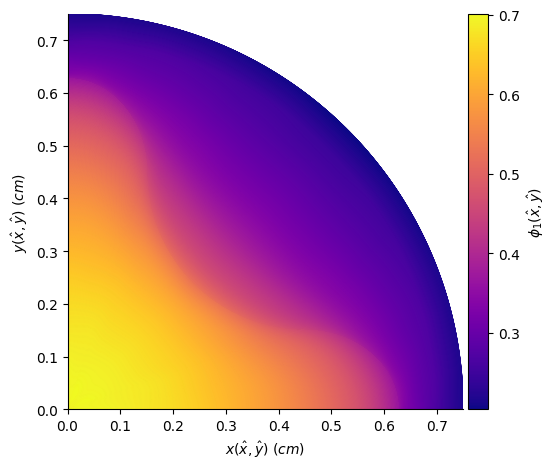

Leakage Fraction = 0.91277


In [9]:
# Set flux
mesh.set_phi(phi[0,])

# Plot
plt.clf()
ax, cbar = mesh.plot(plot_ctrlpts=False)
cbar.set_label("$\\phi_1(\\hat{x}, \\hat{y})$")
plt.tight_layout()
plt.savefig("./figs/phi_1.png", dpi=300)
plt.show()

leakage_frac_openmc = [0.354235, 2.173568e-05]

leakage = assembler.outward_current(psi)
production = assembler.total_production()
leakage_frac = round(float(leakage / production), 5)
print(f"Leakage Fraction = {leakage_frac}")
#print("Leakage fraction error: {} -/+ {}".format(
#    leakage_frac - leakage_frac_openmc[0], leakage_frac_openmc[1])
#)